# Глава 1. Первичный анализ табличных данных

Набор данных: **Medical Insurance Price Prediction**.  
Задача: прогнозирование страховых расходов (`charges`) на основе характеристик клиента.


## 1. Импорт библиотек


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Загрузка данных


In [3]:
import kagglehub

# Загрузка актуальной версии датасета из Kaggle
path = kagglehub.dataset_download("harishkumardatalab/medical-insurance-price-prediction")

print("Path to dataset files:", path)


100%|██████████| 31.6k/31.6k [00:00<00:00, 20.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/harishkumardatalab/medical-insurance-price-prediction/versions/1


In [4]:
# Чтение CSV-файла с данными
df = pd.read_csv(path + '/Medical_insurance.csv')

# Просмотр первых строк
# df.head()


## 3. Визуализация распределения признаков


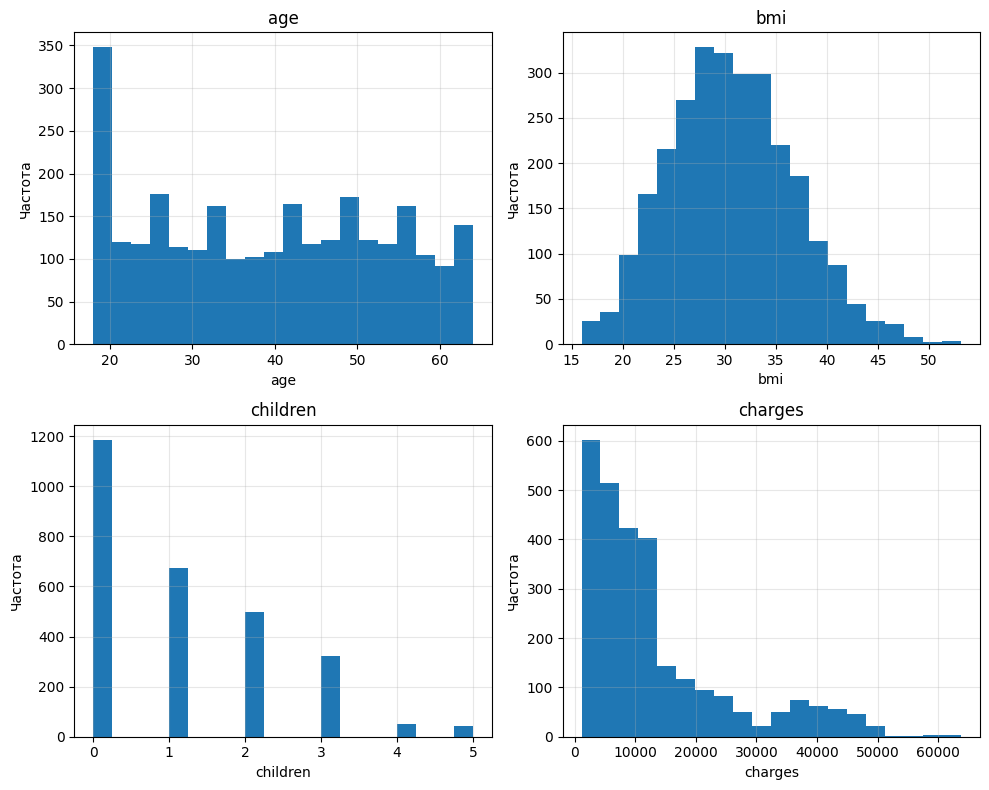

In [5]:
# Список числовых признаков
numeric_columns = ["age", "bmi", "children", "charges"]

plt.figure(figsize=(10, 8))

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(2, 2, i)
    plt.hist(df[col], bins=20)
    plt.title(f"{col}")
    plt.xlabel(col)
    plt.ylabel("Частота")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Рисунок 1.** Графики распределения числовых признаков.


## 4. Визуализация взаимосвязей признаков с целевой переменной


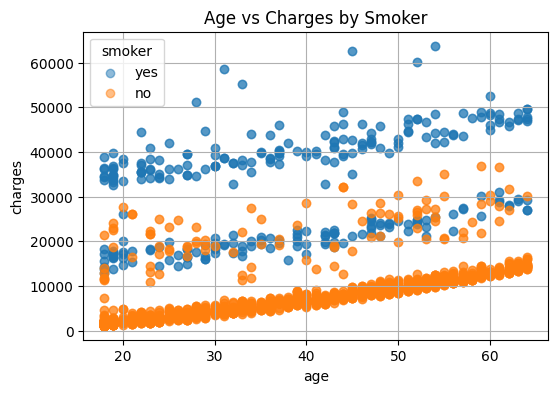

In [9]:
# Зависимость расходов от возраста с учётом статуса курения
plt.figure(figsize=(6, 4))

for smoker_value in df['smoker'].unique():
    subset = df[df['smoker'] == smoker_value]
    plt.scatter(subset['age'], subset['charges'], alpha=0.5, label=smoker_value)

plt.title('Age vs Charges by Smoker')
plt.xlabel('age')
plt.ylabel('charges')
plt.legend(title='smoker')
plt.grid(True)
plt.show()


**Рисунок 2.** График зависимости страховых расходов от возраста с учётом статуса курения.


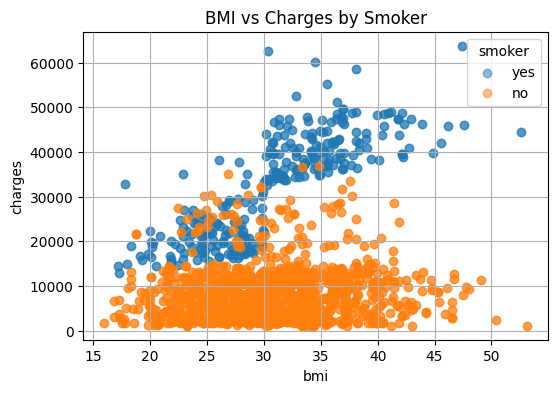

In [9]:
# Зависимость расходов от BMI с учётом статуса курения
plt.figure(figsize=(6, 4))

for smoker_value in df['smoker'].unique():
    subset = df[df['smoker'] == smoker_value]
    plt.scatter(subset['bmi'], subset['charges'], alpha=0.5, label=smoker_value)

plt.title('BMI vs Charges by Smoker')
plt.xlabel('bmi')
plt.ylabel('charges')
plt.legend(title='smoker')
plt.grid(True)
plt.show()


**Рисунок 3.** График зависимости страховых расходов от индекса массы тела с учётом статуса курения.


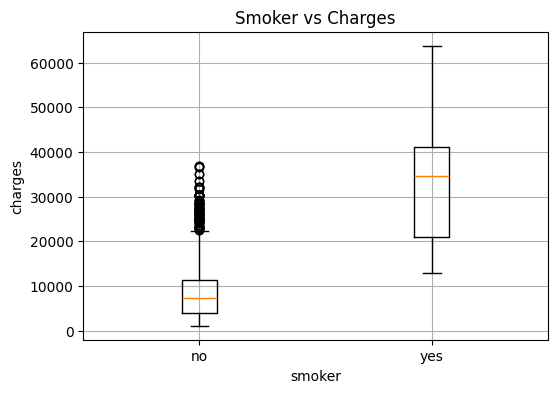

In [9]:
# Зависимость расходов от статуса курения
plt.figure(figsize=(6, 4))
plt.boxplot(
    [df[df['smoker'] == value]['charges'] for value in ['no', 'yes']],
    tick_labels=['no', 'yes']
)
plt.title('Smoker vs Charges')
plt.xlabel('smoker')
plt.ylabel('charges')
plt.grid(True)
plt.show()


**Рисунок 4.** График зависимости страховых расходов от статуса курения.


## 5. Анализ пропущенных значений


In [17]:
# Проверка количества пропущенных значений по каждому признаку
df.isnull().sum()


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## 6. Корреляционный анализ


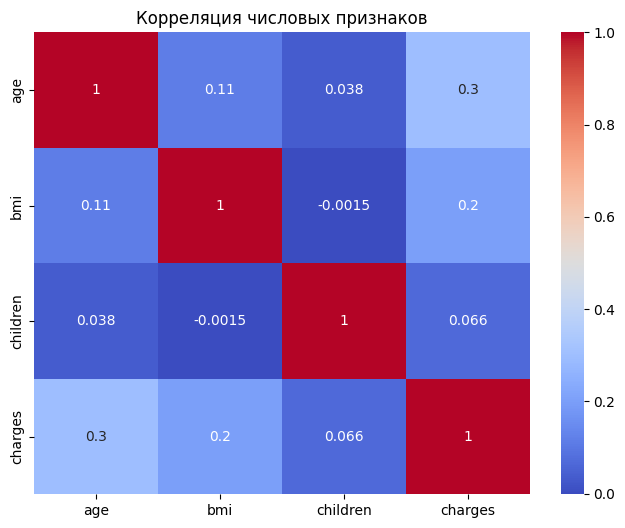

In [10]:
# Тепловая карта корреляции числовых признаков
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Корреляция числовых признаков')
plt.show()


**Рисунок 5.** Тепловая карта корреляции числовых признаков.


## 7. Устранение дубликатов


In [28]:
# Проверка количества дубликатов
print("Количество дубликатов:", df.duplicated().sum())

# Удаление дубликатов
df = df.drop_duplicates()

# Проверка количества дубликатов после удаления
print("После удаления:", df.duplicated().sum())


Количество дубликатов: 0
После удаления: 0


## 8. Анализ выбросов


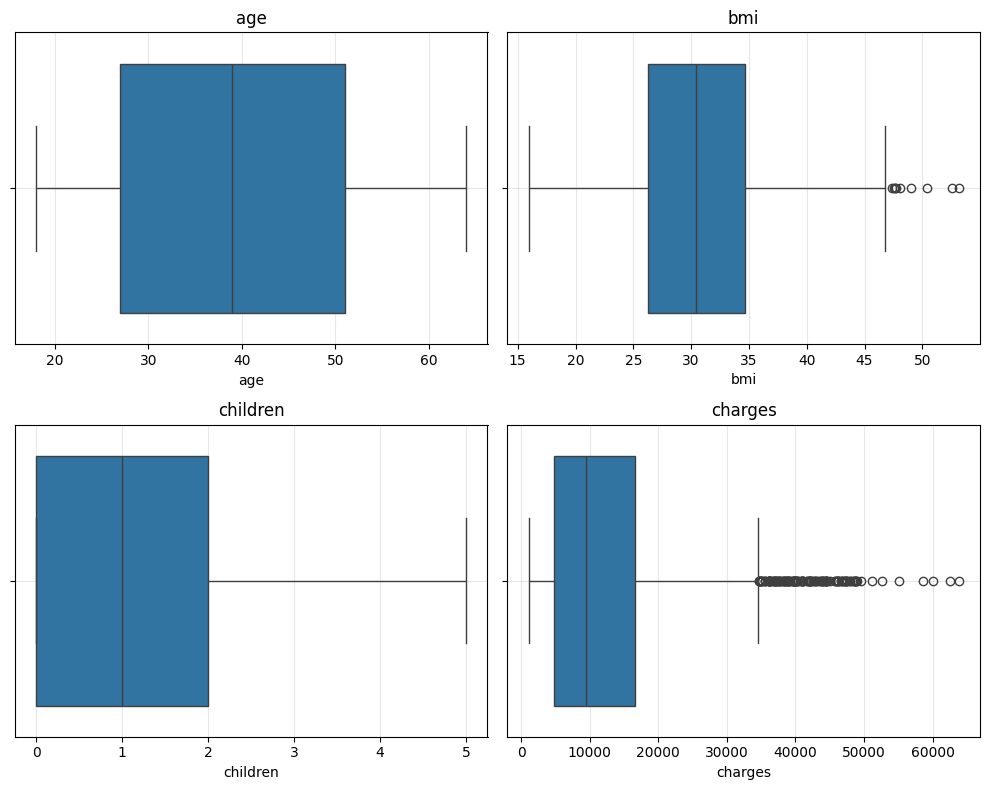

In [29]:
# Диаграммы размаха для числовых признаков
numeric_cols = ["age", "bmi", "children", "charges"]

plt.figure(figsize=(10, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f"{col}")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Рисунок 6.** Диаграммы размаха для числовых признаков.


## 9. Фильтрация данных


In [7]:
# Курящие клиенты
smokers = df[df['smoker'] == 'yes']

# Клиенты с высоким BMI
high_bmi = df[df['bmi'] > 30]

# Группа риска: курящие клиенты с BMI выше 30
risk_group = df[(df['smoker'] == 'yes') & (df['bmi'] > 30)]

print("Количество записей в подвыборках:")
print("Курящие клиенты:", len(smokers))
print("Клиенты с BMI > 30:", len(high_bmi))
print("Группа риска:", len(risk_group))

print("
Средние страховые расходы:")
print("Все клиенты:", round(df['charges'].mean(), 2))
print("Курящие клиенты:", round(smokers['charges'].mean(), 2))
print("Клиенты с BMI > 30:", round(high_bmi['charges'].mean(), 2))
print("Группа риска:", round(risk_group['charges'].mean(), 2))


Количество записей в подвыборках:
Курящие клиенты: 564
Клиенты с BMI > 30: 1466
Группа риска: 302

Средние страховые расходы:
Все клиенты: 13261.37
Курящие клиенты: 32223.14
Клиенты с BMI > 30: 15573.47
Группа риска: 41672.02


## 10. Добавление шума


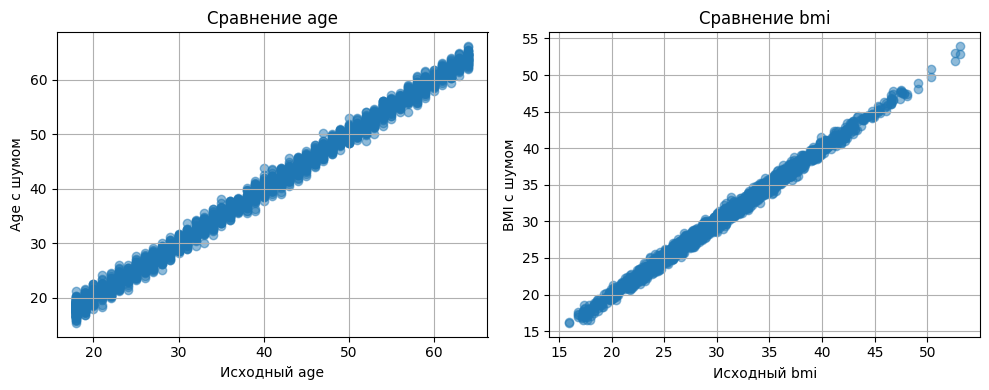

In [6]:
np.random.seed(42)

df_noise = df.copy()

# Добавление небольшого случайного шума к двум нецелевым признакам
df_noise['age_noise'] = df_noise['age'] + np.random.normal(0, 1, size=len(df_noise))
df_noise['bmi_noise'] = df_noise['bmi'] + np.random.normal(0, 0.5, size=len(df_noise))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(df_noise['age'], df_noise['age_noise'], alpha=0.5)
axes[0].set_title('Сравнение age')
axes[0].set_xlabel('Исходный age')
axes[0].set_ylabel('Age с шумом')
axes[0].grid(True)

axes[1].scatter(df_noise['bmi'], df_noise['bmi_noise'], alpha=0.5)
axes[1].set_title('Сравнение bmi')
axes[1].set_xlabel('Исходный bmi')
axes[1].set_ylabel('BMI с шумом')
axes[1].grid(True)

plt.tight_layout()
plt.show()


**Рисунок 7.** Сравнение исходных и модифицированных признаков после добавления шума.


## 11. Краткий вывод

В ноутбуке выполнен первичный анализ табличного набора данных: загружены данные, построены основные визуализации, проверены пропуски и дубликаты, выполнен корреляционный анализ, анализ выбросов, фильтрация подгрупп и добавление шума к двум нецелевым признакам.
